# Amazon Product Recommendation System in Python
Recommendation systems are a core application of data science for digital products and services. As a large e‑commerce platform, Amazon relies on personalized suggestions to help shoppers discover relevant items and improve their overall experience. In this project, we will walk through creating a simple Amazon‑style recommender using Python.

## Project Overview
Our approach focuses on product‑to‑product recommendations: we estimate how similar items are and suggest the closest matches to users based on what they viewed or rated. Choosing an effective way to measure similarity between products is an active area of research and has a big impact on recommendation quality.

At marketplace scale, it also helps to incorporate product quality signals—reviews and ratings—alongside similarity. In this project, we combine item similarity with review information to surface better suggestions. You can find a suitable dataset on Kaggle: [Amazon Product Reviews](https://www.kaggle.com/saurav9786/amazon-product-reviews).

## 1. Importing Libraries
First, let's import the necessary libraries.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

import warnings

### Configuration
Let's configure the necessary settings.

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Data Loading
Next, we will load the dataset into a pandas DataFrame and take a quick look at its structure.

In [3]:
df = pd.read_csv('ratings_Electronics.csv', names=['user_id', 'product_id','rating','timestamp'])

In [4]:
df.head()

,user_id,product_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [5]:
df.size

31297928

Dataset is quite large. Let's select users who have more than 100 ratings.

In [6]:
# Keep only rows for users with > 100 ratings
user_rating_counts = df['user_id'].value_counts()
df = df[df['user_id'].map(user_rating_counts) > 100]
df.shape

(43309, 4)

In [7]:
df.reset_index(drop=True, inplace=True)

## 3. Data Visualization
Next, let's visualize the dataset.

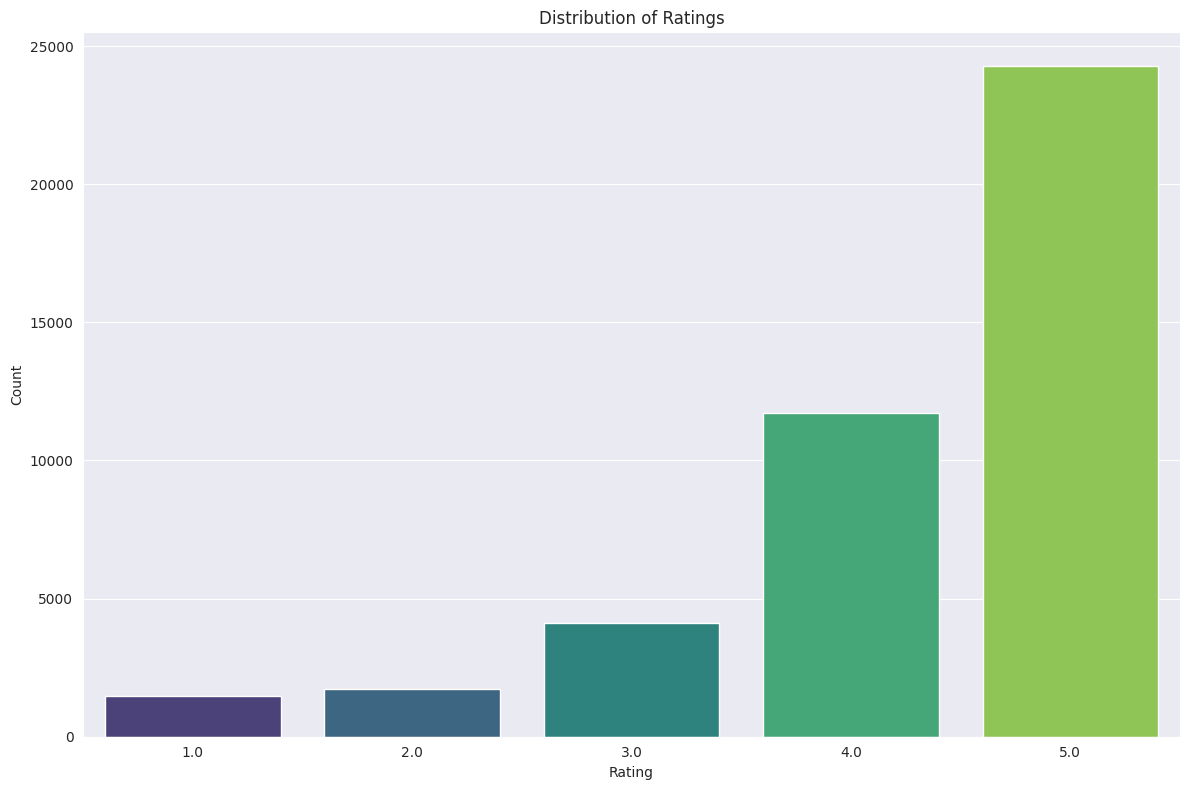

In [8]:
sns.countplot(x=df.rating, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()

In [9]:
df.rating.describe()

count    43309.000000
mean         4.284029
std          1.020311
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

In [10]:
df['timestamp'] = pd.to_datetime(df.timestamp, unit='s')

In [11]:
df.timestamp.describe()

count                            43309
mean     2011-08-04 12:11:01.331362816
min                1999-12-01 00:00:00
25%                2010-03-21 00:00:00
50%                2012-05-16 00:00:00
75%                2013-07-22 00:00:00
max                2014-07-23 00:00:00
Name: timestamp, dtype: object

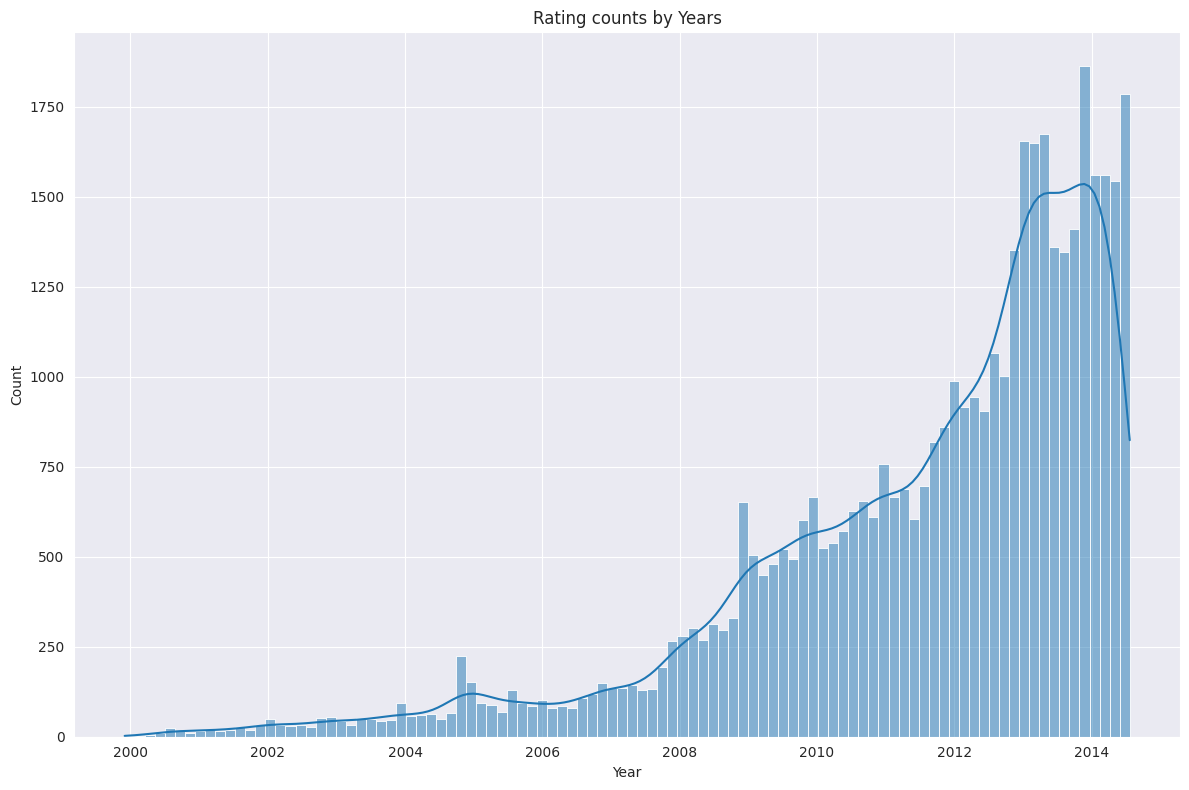

In [12]:
sns.histplot(df.timestamp, bins=100, kde=True)
plt.title('Rating counts by Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()

In [13]:
df.product_id.nunique()

22267

In [14]:
df.user_id.nunique()

280

## 4. Data Preprocessing
Let's make the data ready for the recommendation system.

In [17]:
df.groupby('product_id')['rating'].mean().sort_values(ascending=False).head(10)

product_id
B000001OMI    5.0
B00LKG1MC8    5.0
B000000O48    5.0
B00LGQ6HL8    5.0
0972683275    5.0
B00L8I6SFY    5.0
B00L43HAY6    5.0
B00L403O94    5.0
1400699169    5.0
1685560148    5.0
Name: rating, dtype: float64

In [45]:
# Build a sparse user–item matrix (users x products)
# Encode ids to consecutive integer indices for efficient sparse matrices
user_cats = df['user_id'].astype('category')
product_cats = df['product_id'].astype('category')
user_index = user_cats.cat.codes.values
product_index = product_cats.cat.codes.values
ratings_values = df['rating'].astype(np.float32).values

num_users = user_cats.cat.categories.size
num_items = product_cats.cat.categories.size

uim_sparse = csr_matrix((ratings_values, (user_index, product_index)), shape=(num_users, num_items))

In [ ]:
# Helper mappings between original ids and matrix indices
product_id_to_col = {pid: idx for idx, pid in enumerate(product_cats.cat.categories)}
col_to_product_id = {idx: pid for pid, idx in product_id_to_col.items()}
user_id_to_row = {uid: idx for idx, uid in enumerate(user_cats.cat.categories)}
row_to_user_id = {idx: uid for uid, idx in user_id_to_row.items()}

User–Item matrix: 280 users x 22267 items | density: 0.6946%


In [48]:
# Compute matrix density (%) and show it
num_of_ratings = uim_sparse.nnz
possible_ratings = uim_sparse.shape[0] * uim_sparse.shape[1]
density = (num_of_ratings / possible_ratings) * 100
print(f"User–Item matrix: {uim_sparse.shape[0]} users x {uim_sparse.shape[1]} items | density: {density:.4f}%")

# Fit an item–item KNN model using cosine similarity
item_knn = NearestNeighbors(metric='cosine', algorithm='brute')
item_knn.fit(uim_sparse.T)

def recommend_similar_products(query_product_id, top_k=10):
    """Return top_k similar product_ids to the query_product_id (excluding itself)."""
    if query_product_id not in product_id_to_col:
        raise ValueError("query_product_id not found in the training data")
    query_col = product_id_to_col[query_product_id]
    distances, indices = item_knn.kneighbors(uim_sparse.T[query_col], n_neighbors=top_k + 1)
    indices = indices.ravel()[1:]
    distances = distances.ravel()[1:]
    return pd.DataFrame({
        'product_id': [col_to_product_id[i] for i in indices],
        'similarity': 1.0 - distances
    })

User–Item matrix: 280 users x 22267 items | density: 0.6946%


In [49]:
# Example: get similar items for a sample product
example_pid = df['product_id'].iloc[0]
print(f"Recommended products for {example_pid}:")
recommendations_example = recommend_similar_products(example_pid, top_k=10)
recommendations_example.head()

Recommended products for 0594481813:


,product_id,similarity
0,B00K6YD3B8,1.0
1,B00JCABMSI,1.0
2,B00ITD5NV6,1.0
3,B00HSC0D3W,1.0
4,B00HNYDU4Y,1.0


In [50]:
# Fit a user–user KNN model (cosine) for user-based recommendations
user_knn = NearestNeighbors(metric='cosine', algorithm='brute')
user_knn.fit(uim_sparse)

def recommend_products_for_user(query_user_id, top_k=10, neighbor_k=50):
    """Recommend products to a user using similar users' preferences.
    Returns top_k product_ids the user hasn't rated yet, scored by similarity-weighted sum.
    """
    if query_user_id not in user_id_to_row:
        raise ValueError("query_user_id not found in the training data")
    query_row = user_id_to_row[query_user_id]

    distances, indices = user_knn.kneighbors(uim_sparse[query_row], n_neighbors=min(neighbor_k + 1, uim_sparse.shape[0]))
    indices = indices.ravel()
    distances = distances.ravel()

    # exclude the user itself if present at first position
    mask = indices != query_row
    neighbor_indices = indices[mask][:neighbor_k]
    neighbor_distances = distances[mask][:neighbor_k]
    similarities = 1.0 - neighbor_distances

    if neighbor_indices.size == 0:
        return pd.DataFrame(columns=['product_id', 'score'])

    neighbor_ratings = uim_sparse[neighbor_indices]
    weighted_scores = similarities @ neighbor_ratings.toarray()

    # zero out items already rated by the user
    user_rated_mask = uim_sparse[query_row].toarray().ravel() > 0
    weighted_scores[user_rated_mask] = -np.inf

    if np.all(~np.isfinite(weighted_scores)):
        return pd.DataFrame(columns=['product_id', 'score'])

    top_cols = np.argpartition(-weighted_scores, kth=min(top_k, len(weighted_scores)-1))[:top_k]
    top_cols = top_cols[np.argsort(-weighted_scores[top_cols])]

    return pd.DataFrame({
        'product_id': [col_to_product_id[c] for c in top_cols],
        'score': weighted_scores[top_cols]
    })

In [51]:
# Example: get user-based recommendations for a sample user
example_uid = df['user_id'].iloc[0]
print(f"Recommended products for user {example_uid}:")
recommendations_user_example = recommend_products_for_user(example_uid, top_k=10, neighbor_k=50)
recommendations_user_example.head()

Recommended products for user AT09WGFUM934H:


,product_id,score
0,B001TH7GUU,1.270554
1,B003ES5ZUU,1.193002
2,B000N99BBC,1.177456
3,B002V88HFE,1.166098
4,B002SZEOLG,1.089521


## 5. Conclusion
In this notebook we built two collaborative filtering recommenders on Amazon ratings data: an item–item model for product-to-product suggestions and a user–user model for personalized recommendations. Using a sparse user–item matrix made the workflow scalable and the density metric highlighted how sparse such datasets are in practice.

Key insights:
- Active-user filtering improves data quality and model stability.
- Item–item similarity (cosine) gives fast, relevant “similar products.”
- User–user recommendations add personalization by leveraging neighbor preferences.

Future improvements:
- Add model-based CF (e.g., ALS/matrix factorization) and implicit feedback.
- Incorporate content/features (titles, categories, text embeddings) for cold-start.
- Use ANN libraries for scalable nearest neighbors and tune hyperparameters.
- Implement proper evaluation (precision@k, recall@k, MAP, AUC) and temporal splits.
- Blend popularity/quality signals (reviews, ratings count) into a hybrid model.